# Notebook 03 TA Answer Key: Algorithms First, Assignment 2 Bridge

This answer key mirrors the current Session 3 student notebook. It keeps Part 1 to three compact algorithm exercises, then gives completed background code for the Assignment 2 bridge.

Use this for TA preparation only. The goal in class is still to give hints first, not finished answers.

## Learning Goals

By the end of this session, students should be able to:

- Turn a plain-English algorithm into a loop.
- Track state while scanning a list.
- Trace binary search and explain why sorted data matters.
- Build the merge step that makes merge sort possible.
- Reason about simple algorithm complexity patterns.
- Use `np.random.choice` to model random outcomes.
- Plan the state variables for a best-of-7 series simulation.

# Part 1: Algorithm Exercises

TA pacing suggestion: keep these brisk. Ask students to predict the edge-case output before running code.

## Exercise 1: Largest Value and Its Position

Write `find_largest_with_index(numbers)`.

Return a tuple: `(largest_value, index_of_largest_value)`.

Requirements:

- Return the first index if the largest value appears more than once.
- Return `None` for an empty list.
- Do not use `max()`.

In [ ]:
def find_largest_with_index(numbers):
    if len(numbers) == 0:
        return None

    largest_value = numbers[0]
    largest_index = 0

    for index, number in enumerate(numbers):
        if number > largest_value:
            largest_value = number
            largest_index = index

    return largest_value, largest_index

print(find_largest_with_index([4, 9, 2, 10, 3]))  # expected: (10, 3)
print(find_largest_with_index([7, 1, 7, 2]))       # expected: (7, 0)
print(find_largest_with_index([]))                 # expected: None

**TA Note:** The strict `>` comparison is what keeps the first index when there is a tie.

**Hint to give:** Ask students what their starting `largest_value` should be if all values are negative.

**Common mistakes:** Starting at `0`, using `>=` and accidentally returning the last tied index, or forgetting the empty-list case.

## Exercise 2: Binary Search with a Guess Counter

Complete `binary_search_count(sorted_items, target)`.

Return a tuple: `(index, guesses)`.

Requirements:

- Return `(-1, guesses)` if the target is absent.
- Count every middle check as one guess.
- Before coding, predict the result for target `25` in `list(range(1, 33))`.

In [ ]:
def binary_search_count(sorted_items, target):
    low = 0
    high = len(sorted_items) - 1
    guesses = 0

    while low <= high:
        guesses += 1
        mid = (low + high) // 2

        if sorted_items[mid] == target:
            return mid, guesses
        elif sorted_items[mid] < target:
            low = mid + 1
        else:
            high = mid - 1

    return -1, guesses

numbers = list(range(1, 33))
print(binary_search_count(numbers, 25))  # expected: (24, 5)
print(binary_search_count(numbers, 40))  # expected: (-1, 6)

### Trace Example for TAs

For `numbers = list(range(1, 33))` and `target = 25`, students should trace how the search interval changes. Remind them that `low`, `mid`, and `high` are indexes, while `numbers[mid]` is the value being checked.

| Guess | low | mid | high | numbers[mid] | Decision |
| --- | ---: | ---: | ---: | ---: | --- |
| 1 | 0 | 15 | 31 | 16 | target is larger, move `low` to 16 |
| 2 | 16 | 23 | 31 | 24 | target is larger, move `low` to 24 |
| 3 | 24 | 27 | 31 | 28 | target is smaller, move `high` to 26 |
| 4 | 24 | 25 | 26 | 26 | target is smaller, move `high` to 24 |
| 5 | 24 | 24 | 24 | 25 | found at index 24 |

In [ ]:
def trace_binary_search(sorted_items, target):
    low = 0
    high = len(sorted_items) - 1
    guess = 0

    while low <= high:
        guess += 1
        mid = (low + high) // 2
        value = sorted_items[mid]

        if value == target:
            decision = "found"
            print(guess, "low=", low, "mid=", mid, "high=", high, "value=", value, decision)
            return mid, guess
        elif value < target:
            decision = "target is larger, move low right"
            print(guess, "low=", low, "mid=", mid, "high=", high, "value=", value, decision)
            low = mid + 1
        else:
            decision = "target is smaller, move high left"
            print(guess, "low=", low, "mid=", mid, "high=", high, "value=", value, decision)
            high = mid - 1

    print("target not found after", guess, "guesses")
    return -1, guess

numbers = list(range(1, 33))
trace_binary_search(numbers, 25)

**TA Note:** For `list(range(1, 33))`, value `25` is at index `24`. This implementation finds it in 5 guesses. The absent value `40` takes 6 middle checks before `low > high`.

**Hint to give:** Ask students which half can be discarded after comparing `sorted_items[mid]` to `target`.

**Common mistakes:** Forgetting `+ 1` or `- 1` when updating bounds, counting guesses outside the loop, or trying binary search on unsorted data.

## Exercise 3: Merge Two Sorted Lists

Merge sort is built on one smaller operation: combine two already-sorted lists into one sorted list.

Write `merge_sorted(left, right)`.

Requirements:

- Return a new sorted list.
- Handle empty lists.
- Keep duplicates.
- Do not use `sorted()`.

In [ ]:
def merge_sorted(left, right):
    merged = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1

    merged.extend(left[i:])
    merged.extend(right[j:])
    return merged

print(merge_sorted([1, 4, 7], [2, 3, 8]))  # expected: [1, 2, 3, 4, 7, 8]
print(merge_sorted([], [2, 2, 5]))          # expected: [2, 2, 5]
print(merge_sorted([1, 3], [1, 2]))         # expected: [1, 1, 2, 3]

**TA Note:** This is the merge step, not full recursive merge sort. Students only need to maintain two indexes and append leftovers.

**Hint to give:** Ask which list has the smaller current front value. Once one list is empty, what remains must already be sorted.

**Common mistakes:** Forgetting leftover items, using `sorted()`, or advancing both indexes after appending one value.

# Part 2: Assignment 2 Bridge

The homework asks students to simulate NBA Finals series. This section gives background pieces and implementation checkpoints without needing to reveal the full homework first.

## Background: What is `np.random`?

`np.random` is NumPy's randomness module. In Assignment 2, students use it to simulate uncertain outcomes.

Useful functions:

- `np.random.choice(options, p=probabilities)` chooses one item from a list of options.
- `np.random.uniform()` returns a random number between 0 and 1.
- `np.random.seed(...)` makes random results repeatable while debugging.

In [2]:
import numpy as np

np.random.seed(1)

print(np.random.choice(["A wins", "B wins"]))
print(np.random.choice([0, 1], p=[0.3, 0.7]))
print(np.random.uniform())

B wins
1
0.9325573593386588


## Homework Function 1: `generate_bernoulli(p)`

A Bernoulli random variable returns either `0` or `1`.

For Assignment 2, interpret:

- `1` as success / team A wins
- `0` as failure / team A does not win

**TA reveal note:** The public student notebook now stops at a scaffold for this homework function. Before showing this completed version, ask students to identify the two possible outcomes, the probability attached to each outcome, and one small test they can run.


In [5]:
def generate_bernoulli(p):
    return np.random.choice([0, 1], p=[1 - p, p])

np.random.seed(1)
for _ in range(10):
    print(generate_bernoulli(0.6))

1
1
0
0
0
0
0
0
0
1


**TA Note:** `p=[1 - p, p]` must line up with options `[0, 1]`. If students reverse the probabilities, their sample mean will be near `1 - p`.

## Debugging `generate_bernoulli`

After the function works once, test it many times and inspect the average. If `p = 0.6`, the sample mean should be near 0.6, but not exactly equal every time.

In [6]:
np.random.seed(1)
results = []

for _ in range(1000):
    results.append(generate_bernoulli(0.6))

print("sample mean:", np.mean(results))
print("first 20 results:", results[:20])

sample mean: 0.611
first 20 results: [np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]


## Homework Function 2: Planning `single_series(team_A, team_B, p_A)`

State variables:

- `team_A_wins`
- `team_B_wins`
- `n_games`
- `game_record`
- one-game winner

## Build `single_series` in Small Pieces

Suggested build order:

1. Initialize counters and an empty `game_record`.
2. Simulate one game winner using `np.random.choice` or `generate_bernoulli`.
3. Update the correct team's counter.
4. Append one record to `game_record`.
5. Check whether either team has reached 4 wins.
6. Return the final summary.

**TA reveal note:** The public student notebook now asks students to design the state and loop before seeing the complete implementation. Guide them with questions first: what changes after one game, what should be recorded, and what condition stops the series? Reveal this full code only after they have an attempt or a hand trace.


In [8]:
def single_series(team_A, team_B, p_A):
    game_record = []
    n_games = 0
    team_A_wins = 0
    team_B_wins = 0

    while team_A_wins < 4 and team_B_wins < 4:
        n_games += 1
        game_result = np.random.choice([team_A, team_B], p=[p_A, 1 - p_A])
        game_record.append((n_games, game_result))

        if game_result == team_A:
            team_A_wins += 1
        else:
            team_B_wins += 1

    winner = team_A if team_A_wins == 4 else team_B
    return n_games, winner, game_record

np.random.seed(1)
result = single_series("Golden State Warriors", "Boston Celtics", 0.6)
print(result)

(5, 'Golden State Warriors', [(1, np.str_('Golden State Warriors')), (2, np.str_('Boston Celtics')), (3, np.str_('Golden State Warriors')), (4, np.str_('Golden State Warriors')), (5, np.str_('Golden State Warriors'))])


**TA Note:** Valid `n_games` values are 4, 5, 6, and 7. `game_record` should have the same length as `n_games`, and the returned winner should have exactly 4 wins in the record.

**Hint to give:** Ask students which variables must change after exactly one game is played.

**Common mistakes:** Infinite loop from not updating counters, returning the last game winner before checking series winner, or appending records in an inconsistent format.

## Mini Tests for `single_series`

In [ ]:
np.random.seed(2)
result = single_series("A", "B", 0.9)
n_games, winner, game_record = result

print("n_games:", n_games)
print("winner:", winner)
print("record:", game_record)
print("n_games is valid:", 4 <= n_games <= 7)
print("record length matches n_games:", len(game_record) == n_games)
print("winner has 4 wins:", sum(1 for _, game_winner in game_record if game_winner == winner) == 4)

Matplotlib is building the font cache; this may take a moment.


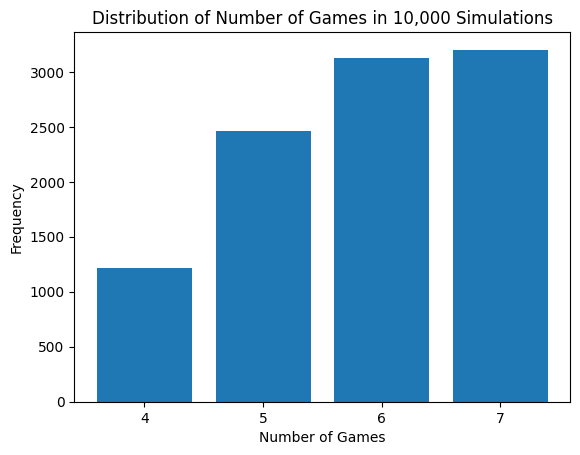

In [10]:
results = []

for _ in range(10000):
    result = single_series("Golden State Warriors", "Boston Celtics", 0.5)
    results.append(result)



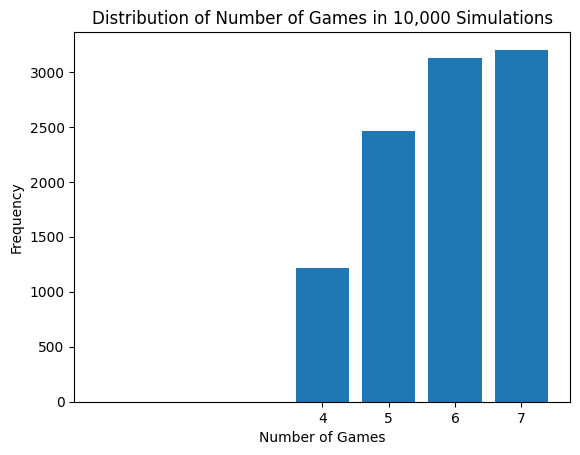

In [ ]:
import matplotlib.pyplot as plt
plt.hist(
    [series[0] for series in results],
    bins=range(1, 10),
    align="left",
    rwidth=0.8
)

plt.xlabel("Number of Games")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Games in 10,000 Simulations")
plt.xticks(range(4, 8))
plt.show()

## Reflection Answer Notes

1. The merge exercise is often the shortest-looking but hardest because it has two indexes and leftover cases.
2. `np.random.choice` chooses one value from a list, optionally using custom probabilities.
3. A best-of-7 simulation needs win counters, game count, a record, and a way to generate each game winner.
4. A common infinite-loop bug is forgetting to update win counters or `n_games`.
5. Before 10,000 simulations, test one series and verify length, winner, and record consistency.